In [1]:
import os
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
from tensorflow.keras.layers import (
    Dense,
    GlobalMaxPooling2D,
    Dropout,
    BatchNormalization,
)
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, confusion_matrix

current_dir = os.getcwd()
if current_dir.endswith("notebooks"):
    os.chdir("..")

# ARAH KE DATA 80:10:10
TRAIN_DIR = os.path.join("data", "patches (80-10-10)", "train")
VAL_DIR = os.path.join("data", "patches (80-10-10)", "val")
TEST_DIR = os.path.join("data", "patches (80-10-10)", "test")

IMG_SIZE = 224
BATCH_SIZE = 16
NUM_CLASSES = 10

train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    brightness_range=[0.8, 1.2],
    rotation_range=5,
)
val_datagen = ImageDataGenerator(preprocessing_function=preprocess_input)
test_datagen = ImageDataGenerator(preprocessing_function=preprocess_input)

train_generator = train_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode="categorical",
)
val_generator = val_datagen.flow_from_directory(
    VAL_DIR,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode="categorical",
)
test_generator = test_datagen.flow_from_directory(
    TEST_DIR,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    shuffle=False,
)

class_weights = compute_class_weight(
    "balanced", classes=np.unique(train_generator.classes), y=train_generator.classes
)
class_weight_dict = dict(enumerate(class_weights))

Found 1837 images belonging to 10 classes.
Found 226 images belonging to 10 classes.
Found 237 images belonging to 10 classes.


In [2]:
inputs = tf.keras.Input(shape=(IMG_SIZE, IMG_SIZE, 3))
base_model = MobileNetV2(
    weights="imagenet", include_top=False, input_shape=(IMG_SIZE, IMG_SIZE, 3)
)
base_model.trainable = False

x = base_model(inputs)
x = GlobalMaxPooling2D()(x)
x = BatchNormalization()(x)
x = Dropout(0.5)(x)
x = Dense(256, activation="relu", kernel_regularizer=tf.keras.regularizers.l2(0.01))(x)
x = Dropout(0.5)(x)
predictions = Dense(NUM_CLASSES, activation="softmax")(x)

model = Model(inputs=inputs, outputs=predictions)

print("[Tahap 1/2] Feature Extraction...")
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss="categorical_crossentropy",
    metrics=["accuracy"],
)
history_phase1 = model.fit(
    train_generator,
    epochs=10,
    validation_data=val_generator,
    class_weight=class_weight_dict,
)

print("\n[Tahap 2/2] Deep Fine-Tuning (Unfreeze 50%)...")
base_model.trainable = True
freeze_until = int(len(base_model.layers) * 0.50)
for layer in base_model.layers[:freeze_until]:
    layer.trainable = False

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=5e-5),
    loss="categorical_crossentropy",
    metrics=["accuracy"],
)
early_stop = EarlyStopping(
    monitor="val_loss", patience=8, restore_best_weights=True, verbose=1
)
reduce_lr = ReduceLROnPlateau(
    monitor="val_loss", factor=0.5, patience=2, min_lr=1e-7, verbose=1
)

history_phase2 = model.fit(
    train_generator,
    epochs=30,
    validation_data=val_generator,
    callbacks=[early_stop, reduce_lr],
    class_weight=class_weight_dict,
)

os.makedirs("models", exist_ok=True)
model.save(os.path.join("models", "mobilenetv2_801010.keras"))
print("Model 80:10:10 berhasil disimpan!")

[Tahap 1/2] Feature Extraction...
Epoch 1/10
115/115 ━━━━━━━━━━━━━━━━━━━━ 97s 784ms/step - accuracy: 0.2983 - loss: 6.9071 - val_accuracy: 0.4912 - val_loss: 5.3937
Epoch 2/10
115/115 ━━━━━━━━━━━━━━━━━━━━ 60s 523ms/step - accuracy: 0.4763 - loss: 5.3912 - val_accuracy: 0.5664 - val_loss: 4.6758
Epoch 3/10
115/115 ━━━━━━━━━━━━━━━━━━━━ 55s 474ms/step - accuracy: 0.5444 - loss: 4.6136 - val_accuracy: 0.6239 - val_loss: 4.0128
Epoch 4/10
115/115 ━━━━━━━━━━━━━━━━━━━━ 55s 478ms/step - accuracy: 0.5939 - loss: 3.9662 - val_accuracy: 0.6549 - val_loss: 3.5692
Epoch 5/10
115/115 ━━━━━━━━━━━━━━━━━━━━ 59s 509ms/step - accuracy: 0.6075 - loss: 3.4855 - val_accuracy: 0.7080 - val_loss: 3.0942
Epoch 6/10
115/115 ━━━━━━━━━━━━━━━━━━━━ 57s 492ms/step - accuracy: 0.6298 - loss: 3.0923 - val_accuracy: 0.7035 - val_loss: 2.7703
Epoch 7/10
115/115 ━━━━━━━━━━━━━━━━━━━━ 59s 511ms/step - accuracy: 0.6478 - loss: 2.7869 - val_accuracy: 0.7434 - val_loss: 2.5185
Epoch 8/10
115/115 ━━━━━━━━━━━━━━━━━━━━ 56s 484ms

15/15 ━━━━━━━━━━━━━━━━━━━━ 6s 414ms/step - accuracy: 0.9873 - loss: 0.6940

Akurasi Test Set (80:10:10): 98.73%

15/15 ━━━━━━━━━━━━━━━━━━━━ 7s 378ms/step
                       precision    recall  f1-score   support

                  151       1.00      1.00      1.00        22
      destined-rivals       1.00      0.96      0.98        25
       evolving-skies       1.00      0.96      0.98        24
     journey-together       0.95      1.00      0.97        19
          lost-origin       0.96      1.00      0.98        26
       paldea-evolved       0.97      1.00      0.98        29
        paldean-fates       1.00      1.00      1.00        25
 prismatic-evolutions       1.00      0.94      0.97        18
scarlet-violet-promos       1.00      1.00      1.00        23
       surging-sparks       1.00      1.00      1.00        26

             accuracy                           0.99       237
            macro avg       0.99      0.99      0.99       237
         weighted avg    

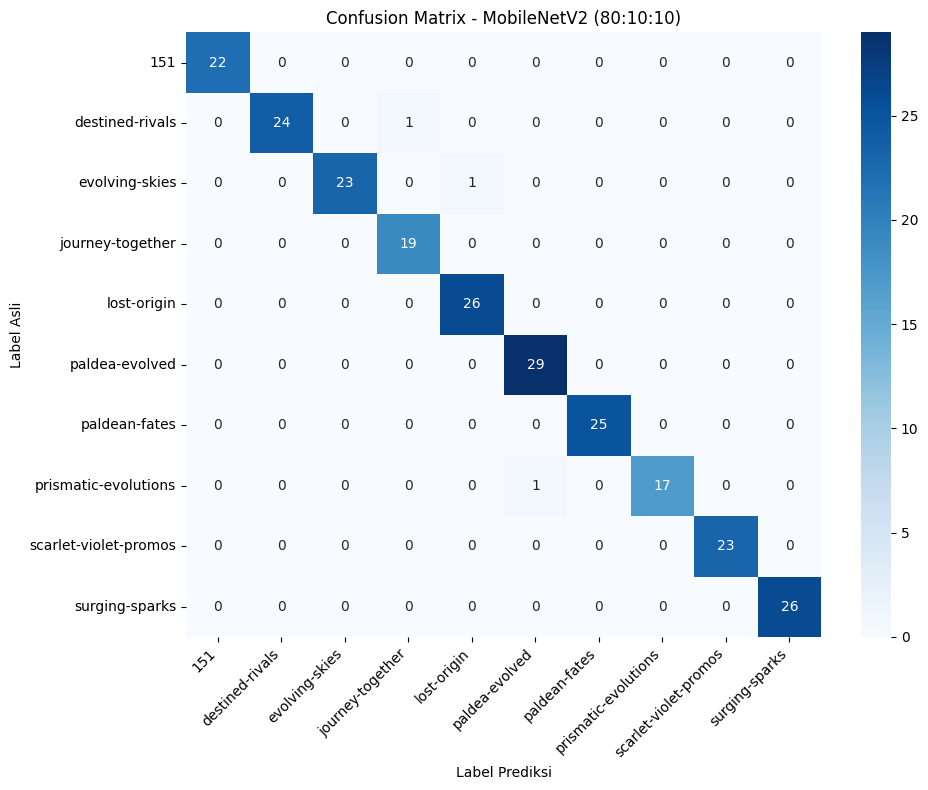

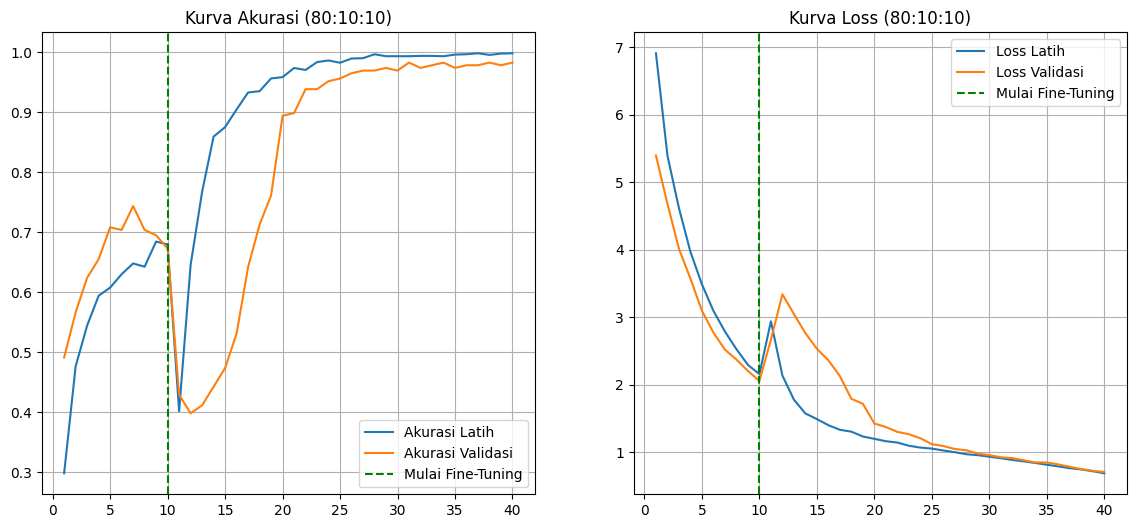

In [3]:
test_loss, test_acc = model.evaluate(test_generator)
print(f"\nAkurasi Test Set (80:10:10): {test_acc * 100:.2f}%\n")

predictions = model.predict(test_generator)
y_pred = np.argmax(predictions, axis=1)
y_true = test_generator.classes
class_names = list(test_generator.class_indices.keys())

print(classification_report(y_true, y_pred, target_names=class_names))

os.makedirs("reports", exist_ok=True)

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names,
)
plt.title("Confusion Matrix - MobileNetV2 (80:10:10)")
plt.ylabel("Label Asli")
plt.xlabel("Label Prediksi")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig(os.path.join("reports", "cm_mobilenet_801010.png"))
plt.show()

# Learning Curves
acc = history_phase1.history["accuracy"] + history_phase2.history["accuracy"]
val_acc = (
    history_phase1.history["val_accuracy"] + history_phase2.history["val_accuracy"]
)
loss = history_phase1.history["loss"] + history_phase2.history["loss"]
val_loss = history_phase1.history["val_loss"] + history_phase2.history["val_loss"]
initial_epochs = len(history_phase1.history["accuracy"])
epochs_range = range(1, len(acc) + 1)

plt.figure(figsize=(14, 6))
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label="Akurasi Latih")
plt.plot(epochs_range, val_acc, label="Akurasi Validasi")
plt.axvline(x=initial_epochs, color="green", linestyle="--", label="Mulai Fine-Tuning")
plt.title("Kurva Akurasi (80:10:10)")
plt.legend(loc="lower right")
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label="Loss Latih")
plt.plot(epochs_range, val_loss, label="Loss Validasi")
plt.axvline(x=initial_epochs, color="green", linestyle="--", label="Mulai Fine-Tuning")
plt.title("Kurva Loss (80:10:10)")
plt.legend(loc="upper right")
plt.grid(True)

plt.savefig(os.path.join("reports", "lc_mobilenet_801010.png"))
plt.show()